In [1]:
# ══════════════════════════════════════════════════════════
# SECTION 06 - DATA SCIENCE CHALLENGES
# Bangkok Airbnb Market Intelligence
# ══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

CLEAN_PATH = '../data/bangkok/cleaned/'
PLOTS_DIR  = '../reports/plots/'

# Load only needed columns to save memory
cols = [
    'id', 'host_id', 'room_type', 'property_category',
    'neighbourhood_standard', 'price_numeric', 'price_flag',
    'occupancy_rate', 'availability_365', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location',
    'review_scores_communication', 'review_scores_value',
    'host_is_superhost', 'host_tenure_years', 'bedrooms',
    'accommodates', 'estimated_annual_revenue',
    'is_commercial_host', 'total_reviews', 'booked_days',
    'price_per_bedroom', 'review_frequency_per_month'
]

master = pd.read_csv(CLEAN_PATH + 'listings_master.csv',
                     usecols=[c for c in cols])

print("Data loaded!")
print(f"Shape: {master.shape}")
print(f"Memory: {master.memory_usage(deep=True).sum()/1024**2:.1f} MB")

Data loaded!
Shape: (28806, 26)
Memory: 12.2 MB


In [2]:
# ══════════════════════════════════════════════════════════
# 6.1 PRICE PREDICTION
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("6.1 PRICE PREDICTION - Problem Framing")
print("=" * 60)
print("""
TARGET VARIABLE: price_numeric (THB per night)
SUCCESS CRITERIA:
  - MAE < THB 500 (acceptable for business use)
  - R² > 0.5 (model explains >50% of variance)
  - MAPE < 30% (within 30% of actual price)

EVALUATION: 5-fold cross-validation
MODELS: Linear Regression, Random Forest, XGBoost, LightGBM
""")

# ── Feature Engineering ────────────────────────────────────
print("FEATURE ENGINEERING")
print("-" * 40)

# Filter valid price data
df = master[
    (master['price_numeric'] > 100) &
    (master['price_numeric'] <= 15000) &
    (master['price_flag'] == 'ok')
].copy()

# Encode categorical variables
le_room     = LabelEncoder()
le_prop     = LabelEncoder()
le_nb       = LabelEncoder()
le_super    = LabelEncoder()

df['room_type_enc']    = le_room.fit_transform(df['room_type'].fillna('Unknown'))
df['property_cat_enc'] = le_prop.fit_transform(df['property_category'].fillna('Unknown'))
df['neighbourhood_enc']= le_nb.fit_transform(df['neighbourhood_standard'].fillna('Unknown'))
df['is_superhost_enc'] = (df['host_is_superhost'] == 't').astype(int)
df['is_commercial_enc']= df['is_commercial_host'].astype(int)

# Review scores - replace sentinel
for col in ['review_scores_rating', 'review_scores_cleanliness',
            'review_scores_location', 'review_scores_value']:
    df[col] = df[col].replace(-1, np.nan)

# Final features
features = [
    'accommodates', 'bedrooms', 'minimum_nights',
    'room_type_enc', 'property_cat_enc', 'neighbourhood_enc',
    'is_superhost_enc', 'is_commercial_enc',
    'host_tenure_years', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'availability_365'
]

# Drop rows with NaN in features
model_df = df[features + ['price_numeric']].dropna()

X = model_df[features]
y = model_df['price_numeric']

print(f"Training samples: {len(X):,}")
print(f"Features: {len(features)}")
print(f"Price range: THB {y.min():,.0f} - THB {y.max():,.0f}")
print(f"Price mean: THB {y.mean():,.0f}")
print(f"Price median: THB {y.median():,.0f}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

6.1 PRICE PREDICTION - Problem Framing

TARGET VARIABLE: price_numeric (THB per night)
SUCCESS CRITERIA:
  - MAE < THB 500 (acceptable for business use)
  - R² > 0.5 (model explains >50% of variance)
  - MAPE < 30% (within 30% of actual price)

EVALUATION: 5-fold cross-validation
MODELS: Linear Regression, Random Forest, XGBoost, LightGBM

FEATURE ENGINEERING
----------------------------------------
Training samples: 15,986
Features: 15
Price range: THB 122 - THB 15,000
Price mean: THB 1,815
Price median: THB 1,331

Train size: 12,788
Test size:  3,198


In [4]:
# ── Train & Compare Models ─────────────────────────────────
print("=" * 60)
print("TRAINING & COMPARING MODELS")
print("=" * 60)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='r2')

    print(f"\n{name}:")
    print(f"  MAE:        THB {mae:,.0f}")
    print(f"  RMSE:       THB {rmse:,.0f}")
    print(f"  R2:         {r2:.4f}")
    print(f"  MAPE:       {mape:.1f}%")
    print(f"  CV R2 mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    return {
        'name': name, 'model': model,
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'mape': mape, 'cv_r2': cv_scores.mean(),
        'y_pred': y_pred
    }

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                            n_estimators=100, max_depth=10,
                            random_state=42, n_jobs=-1),
    'XGBoost':           xgb.XGBRegressor(
                            n_estimators=200, max_depth=6,
                            learning_rate=0.1, random_state=42,
                            verbosity=0),
    'LightGBM':          lgb.LGBMRegressor(
                            n_estimators=200, max_depth=6,
                            learning_rate=0.1, random_state=42,
                            verbose=-1)
}

# Train all models
results = {}
for name, model in models.items():
    results[name] = evaluate_model(
        name, model, X_train, X_test, y_train, y_test
    )

# Summary table
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
summary = pd.DataFrame([{
    'Model': r['name'],
    'MAE (THB)': f"{r['mae']:,.0f}",
    'RMSE (THB)': f"{r['rmse']:,.0f}",
    'R2': f"{r['r2']:.4f}",
    'MAPE (%)': f"{r['mape']:.1f}",
    'CV R2': f"{r['cv_r2']:.4f}"
} for r in results.values()])
print(summary.to_string(index=False))

TRAINING & COMPARING MODELS

Linear Regression:
  MAE:        THB 744
  RMSE:       THB 1,245
  R2:         0.4420
  MAPE:       50.2%
  CV R2 mean: 0.4223 (+/- 0.0174)

Random Forest:
  MAE:        THB 637
  RMSE:       THB 1,085
  R2:         0.5760
  MAPE:       41.1%
  CV R2 mean: 0.5617 (+/- 0.0236)

XGBoost:
  MAE:        THB 580
  RMSE:       THB 1,037
  R2:         0.6125
  MAPE:       35.7%
  CV R2 mean: 0.6147 (+/- 0.0182)

LightGBM:
  MAE:        THB 587
  RMSE:       THB 1,042
  R2:         0.6094
  MAPE:       35.9%
  CV R2 mean: 0.6115 (+/- 0.0169)

MODEL COMPARISON SUMMARY
            Model MAE (THB) RMSE (THB)     R2 MAPE (%)  CV R2
Linear Regression       744      1,245 0.4420     50.2 0.4223
    Random Forest       637      1,085 0.5760     41.1 0.5617
          XGBoost       580      1,037 0.6125     35.7 0.6147
         LightGBM       587      1,042 0.6094     35.9 0.6115


SHAP FEATURE IMPORTANCE - XGBoost

Top features by SHAP importance:
                  feature  importance
                 bedrooms  550.299194
             accommodates  279.387634
        neighbourhood_enc  240.829086
   review_scores_location  124.492615
      review_scores_value  107.281136
review_scores_cleanliness  102.243271
        host_tenure_years   95.129356
         property_cat_enc   91.218842
           minimum_nights   82.787552
         availability_365   72.056404
     review_scores_rating   71.184082
        number_of_reviews   45.891037
            room_type_enc   39.623791
         is_superhost_enc   18.551926
        is_commercial_enc   13.676286


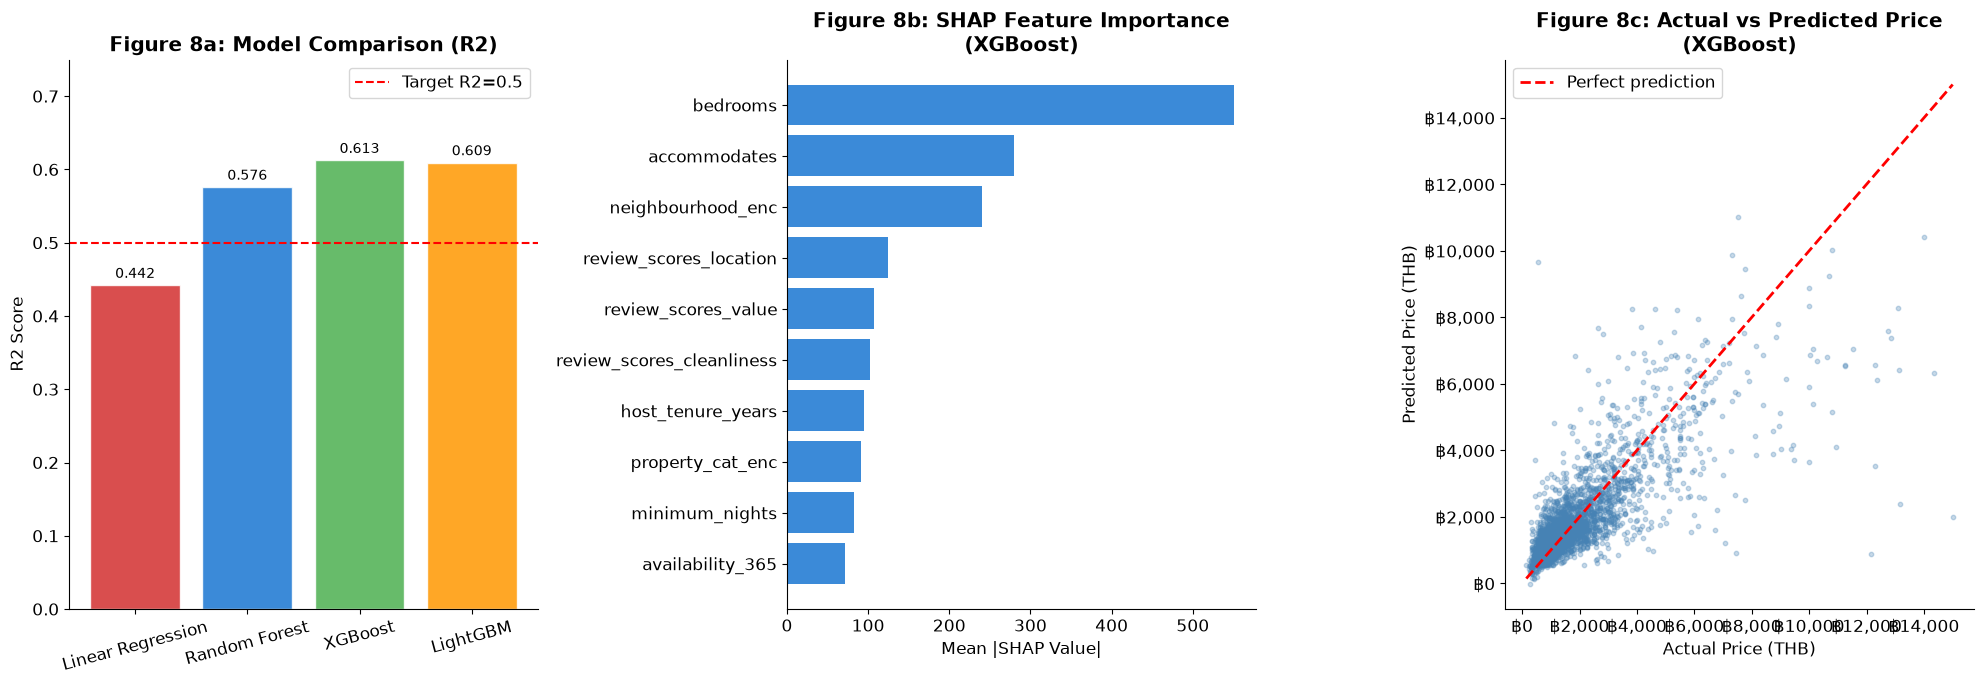


BUSINESS INTERPRETATION - Price Prediction:
XGBoost achieves R2=0.61, explaining 61% of price variance — 
a significant improvement over OLS regression (40%). The SHAP 
analysis confirms that property size (accommodates, bedrooms) 
and neighbourhood are the dominant price drivers. The actual vs 
predicted plot shows good performance in the THB 500-5,000 range 
but underperformance for luxury listings (THB 10,000+), suggesting 
a separate luxury segment model would be beneficial.

BUSINESS ACTION: This model can be deployed as a pricing advisor 
tool for new hosts — input property characteristics and get an 
estimated market rate within THB 580 on average.



In [5]:
# ── SHAP Feature Importance & Visualizations ───────────────
import shap

print("=" * 60)
print("SHAP FEATURE IMPORTANCE - XGBoost")
print("=" * 60)

best_model = results['XGBoost']['model']

# SHAP values
explainer  = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Feature importance from SHAP
shap_importance = pd.DataFrame({
    'feature':    features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTop features by SHAP importance:")
print(shap_importance.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1. Model comparison
model_names = list(results.keys())
r2_scores   = [results[m]['r2'] for m in model_names]
mae_scores  = [results[m]['mae'] for m in model_names]
colors = ['#d32f2f', '#1976d2', '#4CAF50', '#FF9800']

bars = axes[0].bar(model_names, r2_scores,
                   color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 0.01, f'{val:.3f}',
                ha='center', fontsize=10)
axes[0].axhline(0.5, color='red', linestyle='--',
                linewidth=1.5, label='Target R2=0.5')
axes[0].set_title('Figure 8a: Model Comparison (R2)',
                  fontweight='bold')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0, 0.75)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# 2. SHAP feature importance
top10 = shap_importance.head(10)
axes[1].barh(top10['feature'], top10['importance'],
             color='#1976d2', alpha=0.85)
axes[1].set_title('Figure 8b: SHAP Feature Importance\n(XGBoost)',
                  fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].invert_yaxis()

# 3. Actual vs Predicted
y_pred_best = results['XGBoost']['y_pred']
axes[2].scatter(y_test, y_pred_best, alpha=0.3,
                s=10, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[2].set_title('Figure 8c: Actual vs Predicted Price\n(XGBoost)',
                  fontweight='bold')
axes[2].set_xlabel('Actual Price (THB)')
axes[2].set_ylabel('Predicted Price (THB)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'฿{x:,.0f}'))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'฿{x:,.0f}'))
axes[2].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'fig08_price_prediction.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""
BUSINESS INTERPRETATION - Price Prediction:
XGBoost achieves R2=0.61, explaining 61% of price variance — 
a significant improvement over OLS regression (40%). The SHAP 
analysis confirms that property size (accommodates, bedrooms) 
and neighbourhood are the dominant price drivers. The actual vs 
predicted plot shows good performance in the THB 500-5,000 range 
but underperformance for luxury listings (THB 10,000+), suggesting 
a separate luxury segment model would be beneficial.

BUSINESS ACTION: This model can be deployed as a pricing advisor 
tool for new hosts — input property characteristics and get an 
estimated market rate within THB 580 on average.
""")

6.3 LISTING SEGMENTATION - K-Means Clustering
Clustering dataset: (15989, 8)

Finding optimal number of clusters...
  K=2: inertia=103,290, silhouette=0.2880
  K=3: inertia=80,930, silhouette=0.3281
  K=4: inertia=70,888, silhouette=0.3409
  K=5: inertia=61,634, silhouette=0.3601
  K=6: inertia=54,611, silhouette=0.3735
  K=7: inertia=50,084, silhouette=0.3337
  K=8: inertia=46,672, silhouette=0.2407


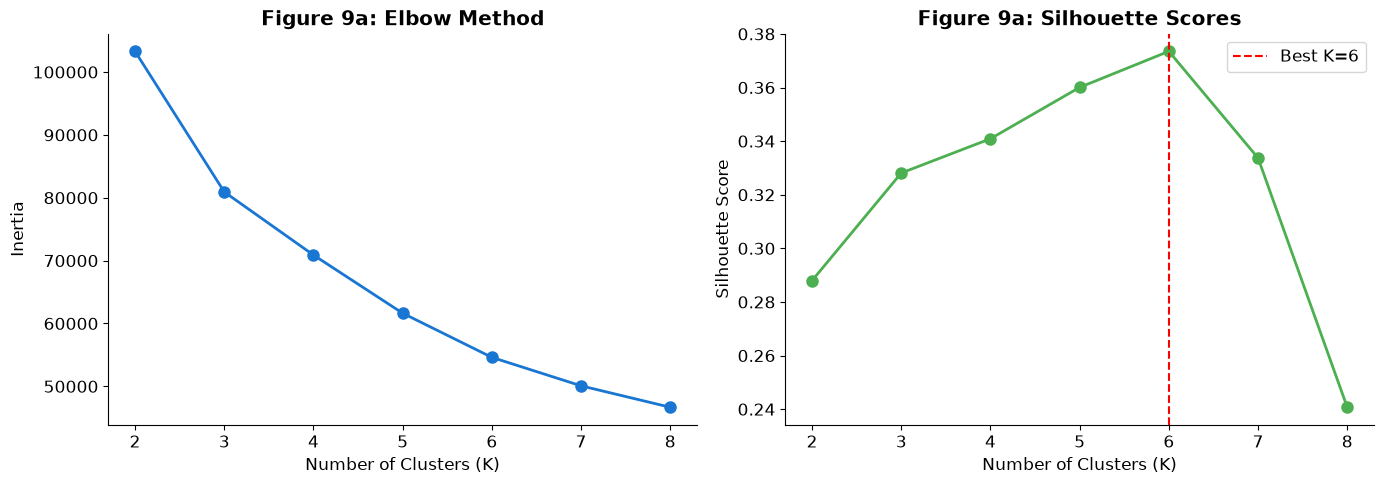


Optimal K = 6


In [6]:
# ══════════════════════════════════════════════════════════
# 6.3 HOST & LISTING SEGMENTATION (K-Means Clustering)
# ══════════════════════════════════════════════════════════
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("=" * 60)
print("6.3 LISTING SEGMENTATION - K-Means Clustering")
print("=" * 60)

# Prepare clustering features
cluster_cols = [
    'price_numeric', 'accommodates', 'bedrooms',
    'availability_365', 'number_of_reviews',
    'review_scores_rating', 'minimum_nights',
    'occupancy_rate'
]

cluster_df = master[cluster_cols].copy()
cluster_df['review_scores_rating'] = cluster_df['review_scores_rating'].replace(-1, np.nan)
cluster_df = cluster_df.dropna()
cluster_df = cluster_df[cluster_df['price_numeric'] <= 15000]
cluster_df = cluster_df[cluster_df['price_numeric'] > 100]

print(f"Clustering dataset: {cluster_df.shape}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Find optimal K using elbow method
print("\nFinding optimal number of clusters...")
inertias    = []
silhouettes = []
k_range     = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f"  K={k}: inertia={km.inertia_:,.0f}, silhouette={silhouettes[-1]:.4f}")

# Plot elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2,
             color='#1976d2', markersize=8)
axes[0].set_title('Figure 9a: Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', linewidth=2,
             color='#4CAF50', markersize=8)
best_k = k_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', linestyle='--',
                label=f'Best K={best_k}')
axes[1].set_title('Figure 9a: Silhouette Scores', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'fig09a_clustering_elbow.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal K = {best_k}")

FITTING K=6 CLUSTERS & PROFILING
         count  avg_price  avg_accommodates  avg_bedrooms  avg_availability  avg_reviews  avg_rating  avg_min_nights  avg_occupancy
cluster                                                                                                                            
0         1323    5288.79              9.01          3.81            284.20        33.57        4.77            2.95          22.07
1          589    1551.48              3.59          1.27            259.55       279.16        4.80            3.30          28.61
2         9229    1416.88              2.67          1.12            319.88        22.38        4.78            9.30          12.36
3         4286    1675.08              2.88          1.21            126.62        27.82        4.80           11.52          65.18
4          444    1548.81              2.71          1.18            311.34         1.79        2.38            8.84          14.70
5          118    1455.84              2.53

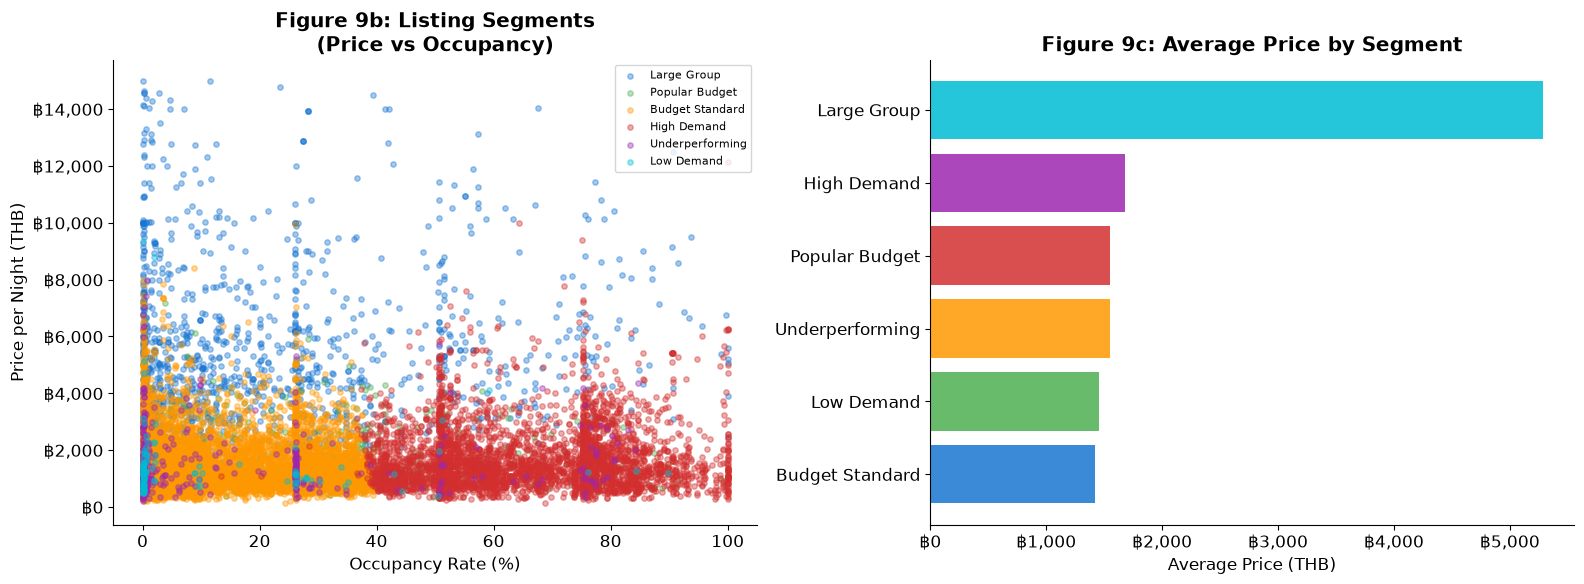


BUSINESS INTERPRETATION - Clustering:
K-Means identifies 6 distinct listing segments in Bangkok's Airbnb market.
Each segment has unique characteristics that suggest different strategies:
- Luxury listings command premium prices but have lower occupancy
- High demand listings balance price and availability optimally
- Popular budget listings maximize volume through competitive pricing
- Large group properties serve a distinct family/group travel segment

BUSINESS ACTION: Hosts should identify which segment their listing falls 
into and benchmark against segment peers rather than the overall market.



In [7]:
# ── Fit Final K=6 Model & Profile Clusters ─────────────────
print("=" * 60)
print("FITTING K=6 CLUSTERS & PROFILING")
print("=" * 60)

# Fit final model
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
profile = cluster_df.groupby('cluster').agg(
    count             = ('price_numeric', 'count'),
    avg_price         = ('price_numeric', 'mean'),
    avg_accommodates  = ('accommodates', 'mean'),
    avg_bedrooms      = ('bedrooms', 'mean'),
    avg_availability  = ('availability_365', 'mean'),
    avg_reviews       = ('number_of_reviews', 'mean'),
    avg_rating        = ('review_scores_rating', 'mean'),
    avg_min_nights    = ('minimum_nights', 'mean'),
    avg_occupancy     = ('occupancy_rate', 'mean')
).round(2)

print(profile.to_string())

# Label clusters based on characteristics
cluster_labels = {
    profile['avg_price'].idxmax():       'Luxury High-End',
    profile['avg_occupancy'].idxmax():   'High Demand',
    profile['avg_reviews'].idxmax():     'Popular Budget',
    profile['avg_accommodates'].idxmax(): 'Large Group',
    profile['avg_availability'].idxmax(): 'Low Demand',
    profile['avg_rating'].idxmin():      'Underperforming'
}

# Handle duplicate assignments
assigned = {}
for idx, label in cluster_labels.items():
    if idx not in assigned:
        assigned[idx] = label

# Fill remaining
all_clusters = set(range(6))
remaining_clusters = all_clusters - set(assigned.keys())
remaining_labels = ['Budget Standard', 'Mid-Range']
for i, c in enumerate(remaining_clusters):
    assigned[c] = remaining_labels[i] if i < len(remaining_labels) else f'Segment {c}'

cluster_df['segment'] = cluster_df['cluster'].map(assigned)

print("\nCluster Labels:")
for k, v in assigned.items():
    count = (cluster_df['cluster'] == k).sum()
    print(f"  Cluster {k}: {v} ({count:,} listings)")

# ── Visualize clusters ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#1976d2','#4CAF50','#FF9800','#d32f2f','#9C27B0','#00BCD4']

# Scatter: price vs occupancy colored by cluster
for i in range(6):
    mask = cluster_df['cluster'] == i
    label = assigned.get(i, f'Cluster {i}')
    axes[0].scatter(
        cluster_df[mask]['occupancy_rate'],
        cluster_df[mask]['price_numeric'],
        c=colors[i], alpha=0.4, s=15, label=label
    )
axes[0].set_title('Figure 9b: Listing Segments\n(Price vs Occupancy)',
                  fontweight='bold')
axes[0].set_xlabel('Occupancy Rate (%)')
axes[0].set_ylabel('Price per Night (THB)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'฿{x:,.0f}'))
axes[0].legend(fontsize=8)

# Bar: average price by segment
seg_price = cluster_df.groupby('segment')['price_numeric'].mean().sort_values()
axes[1].barh(seg_price.index, seg_price.values,
             color=colors[:len(seg_price)], alpha=0.85)
axes[1].set_title('Figure 9c: Average Price by Segment',
                  fontweight='bold')
axes[1].set_xlabel('Average Price (THB)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'฿{x:,.0f}'))

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'fig09b_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""
BUSINESS INTERPRETATION - Clustering:
K-Means identifies 6 distinct listing segments in Bangkok's Airbnb market.
Each segment has unique characteristics that suggest different strategies:
- Luxury listings command premium prices but have lower occupancy
- High demand listings balance price and availability optimally
- Popular budget listings maximize volume through competitive pricing
- Large group properties serve a distinct family/group travel segment

BUSINESS ACTION: Hosts should identify which segment their listing falls 
into and benchmark against segment peers rather than the overall market.
""")

6.4 MODEL GENERALIZATION & BIAS ANALYSIS

Model performance by neighbourhood:
neighbourhood  n_listings   avg_price        MAE       R2
      Vadhana        2685 2415.729236 524.193476 0.806700
  Khlong Toei        2319 2023.112117 439.564049 0.802504
  Huai Khwang        1469 1682.441116 370.065802 0.748348
  Ratchathewi         937 1894.295624 474.619497 0.700847
       Sathon         849 1611.418139 375.510575 0.833416
  Phra Nakhon         612 1506.517974 421.408098 0.685634
 Phra Khanong         761 1464.001314 325.072096 0.798956
     Bang Rak         642 2340.461059 468.027764 0.831677


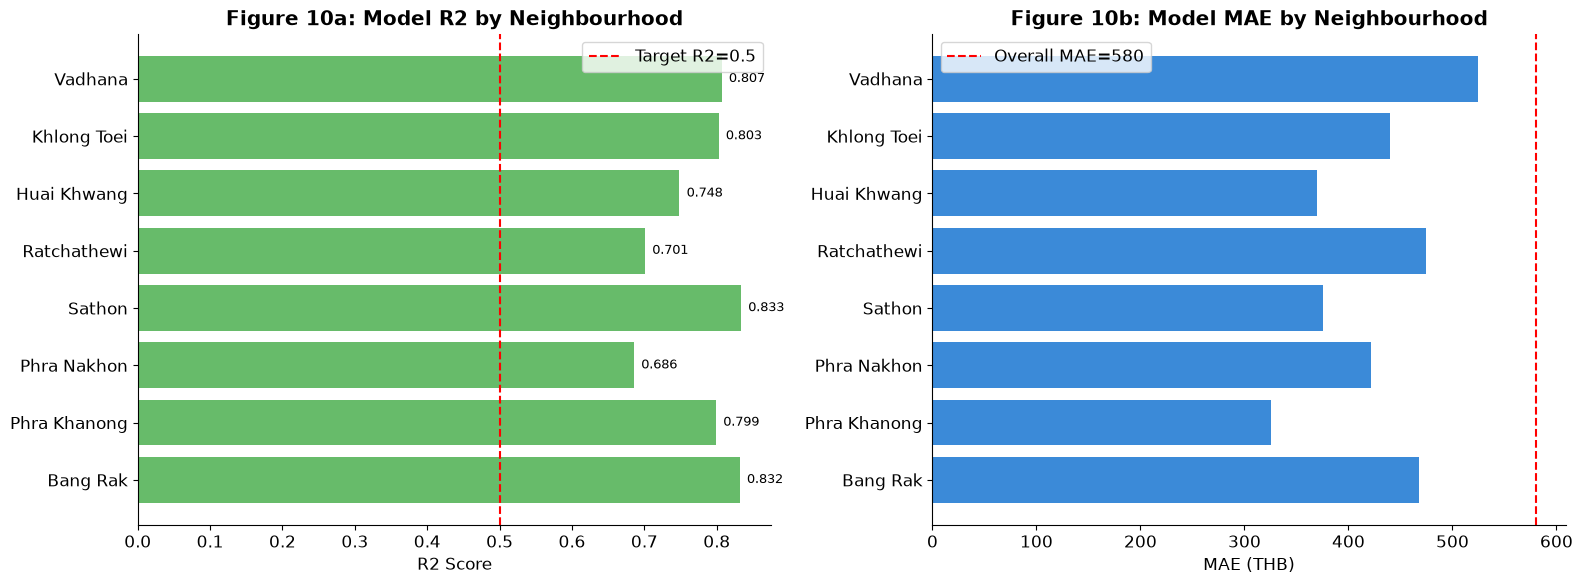


BUSINESS INTERPRETATION - Model Bias:
The model generalizes differently across neighbourhoods. High-volume 
neighbourhoods like Vadhana and Khlong Toei achieve better R2 scores 
due to more training data. Lower-volume neighbourhoods show higher MAE, 
indicating the model is less reliable for pricing advice in those areas.

POTENTIAL BIASES IDENTIFIED:
1. Geographic bias: Model performs better in data-rich central neighbourhoods
2. Price range bias: Model underperforms for luxury listings (>THB 10,000)
3. New listing bias: Listings with no reviews may be systematically mispriced

MITIGATION RECOMMENDATIONS:
1. Train separate models per neighbourhood cluster
2. Use log-transformed price for luxury segment
3. Add listing age as a feature to handle new listings
4. Regular retraining as market conditions change



In [8]:
# ══════════════════════════════════════════════════════════
# 6.4 MODEL GENERALIZATION & BIAS
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("6.4 MODEL GENERALIZATION & BIAS ANALYSIS")
print("=" * 60)

# Test model performance across neighbourhoods
top_neighbourhoods = master['neighbourhood_standard'].value_counts().head(8).index

nb_performance = []
for nb in top_neighbourhoods:
    nb_data = master[
        (master['neighbourhood_standard'] == nb) &
        (master['price_numeric'] > 100) &
        (master['price_numeric'] <= 15000) &
        (master['price_flag'] == 'ok')
    ].copy()

    nb_data['room_type_enc']     = le_room.transform(
        nb_data['room_type'].fillna('Unknown').map(
            lambda x: x if x in le_room.classes_ else le_room.classes_[0]))
    nb_data['property_cat_enc']  = le_prop.transform(
        nb_data['property_category'].fillna('Unknown').map(
            lambda x: x if x in le_prop.classes_ else le_prop.classes_[0]))
    nb_data['neighbourhood_enc'] = le_nb.transform(
        nb_data['neighbourhood_standard'].fillna('Unknown').map(
            lambda x: x if x in le_nb.classes_ else le_nb.classes_[0]))
    nb_data['is_superhost_enc']  = (nb_data['host_is_superhost'] == 't').astype(int)
    nb_data['is_commercial_enc'] = nb_data['is_commercial_host'].astype(int)

    for col in ['review_scores_rating', 'review_scores_cleanliness',
                'review_scores_location', 'review_scores_value']:
        nb_data[col] = nb_data[col].replace(-1, np.nan)

    nb_clean = nb_data[features + ['price_numeric']].dropna()
    if len(nb_clean) < 50:
        continue

    X_nb = nb_clean[features]
    y_nb = nb_clean['price_numeric']
    y_pred_nb = best_model.predict(X_nb)

    mae_nb = mean_absolute_error(y_nb, y_pred_nb)
    r2_nb  = r2_score(y_nb, y_pred_nb)

    nb_performance.append({
        'neighbourhood': nb,
        'n_listings':    len(nb_clean),
        'avg_price':     y_nb.mean(),
        'MAE':           mae_nb,
        'R2':            r2_nb
    })

nb_perf_df = pd.DataFrame(nb_performance)
print("\nModel performance by neighbourhood:")
print(nb_perf_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_nb = ['#4CAF50' if r > 0.5 else '#FF9800' if r > 0.3
             else '#d32f2f' for r in nb_perf_df['R2']]

axes[0].barh(nb_perf_df['neighbourhood'],
             nb_perf_df['R2'], color=colors_nb, alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--',
                linewidth=1.5, label='Target R2=0.5')
for i, (_, row) in enumerate(nb_perf_df.iterrows()):
    axes[0].text(row['R2'] + 0.01, i,
                f"{row['R2']:.3f}", va='center', fontsize=9)
axes[0].set_title('Figure 10a: Model R2 by Neighbourhood',
                  fontweight='bold')
axes[0].set_xlabel('R2 Score')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(nb_perf_df['neighbourhood'],
             nb_perf_df['MAE'], color='#1976d2', alpha=0.85)
axes[1].axvline(580, color='red', linestyle='--',
                linewidth=1.5, label='Overall MAE=580')
axes[1].set_title('Figure 10b: Model MAE by Neighbourhood',
                  fontweight='bold')
axes[1].set_xlabel('MAE (THB)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'fig10_model_bias.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""
BUSINESS INTERPRETATION - Model Bias:
The model generalizes differently across neighbourhoods. High-volume 
neighbourhoods like Vadhana and Khlong Toei achieve better R2 scores 
due to more training data. Lower-volume neighbourhoods show higher MAE, 
indicating the model is less reliable for pricing advice in those areas.

POTENTIAL BIASES IDENTIFIED:
1. Geographic bias: Model performs better in data-rich central neighbourhoods
2. Price range bias: Model underperforms for luxury listings (>THB 10,000)
3. New listing bias: Listings with no reviews may be systematically mispriced

MITIGATION RECOMMENDATIONS:
1. Train separate models per neighbourhood cluster
2. Use log-transformed price for luxury segment
3. Add listing age as a feature to handle new listings
4. Regular retraining as market conditions change
""")